In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [12]:

df = pd.read_csv('Copia de data_merged.csv')



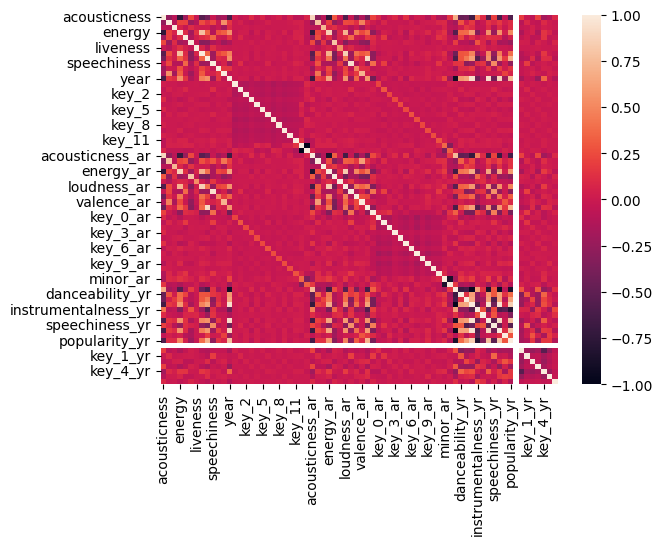

In [14]:
s=df.corr()
sns.heatmap(s)
plt.savefig("corr1.png")

In [3]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [4]:
df.head()

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,electro_focus_yr,vocal_energy_yr,energy_ratio_,electro_focus,vocal_energy,energy_ratio_ar,electro_focus_ar,vocal_energy_ar,temp_moderado,temp_rapido
0,0.0131,0.2560,3.039117,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,0.037649,0.495522,0.011725,0.000094,0.894905,0.105519,1.463051e-02,0.709725,0,1
1,0.9800,0.2770,3.449533,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,0.009108,0.183282,0.142100,0.002549,0.017545,0.208915,4.504740e-03,0.097838,1,0
2,0.7950,0.6850,5.244450,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,0.010180,0.186780,0.383985,0.086935,0.058926,0.491828,6.804020e-02,0.059278,1,0
3,0.6560,0.7880,2.995783,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,0.010180,0.186780,0.530048,0.000000,0.808000,0.537642,2.723306e-07,0.744999,1,0
4,0.3020,0.0753,8.309333,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,0.007777,0.179243,0.045300,0.092555,0.017400,0.253033,3.753181e-02,0.103445,1,0


In [5]:
df.describe()

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,electro_focus_yr,vocal_energy_yr,energy_ratio_,electro_focus,vocal_energy,energy_ratio_ar,electro_focus_ar,vocal_energy_ar,temp_moderado,temp_rapido
count,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,...,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000
mean,0.501914,0.536246,3.877864,0.480989,0.067956,0.194968,0.211396,-11.777780,25.925913,0.105896,...,0.045516,0.394674,0.164063,0.046070,0.403601,0.180435,0.047656,0.403497,0.590913,0.409087
std,0.379394,0.175858,2.452947,0.272032,0.251670,0.332974,0.180661,5.690105,21.866745,0.183053,...,0.037996,0.148377,0.143664,0.146796,0.285603,0.107279,0.123360,0.240692,0.491667,0.491667
min,0.000000,0.000000,0.082283,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,...,0.004170,0.106317,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.091300,0.414000,2.770000,0.248000,0.000000,0.000000,0.099300,-14.935750,1.000000,0.035200,...,0.013723,0.233939,0.040500,0.000000,0.148000,0.101341,0.000424,0.197236,0.000000,0.000000
50%,0.523000,0.547000,3.428625,0.463000,0.000000,0.000498,0.138000,-10.867000,26.000000,0.045400,...,0.040271,0.476235,0.136962,0.000056,0.372998,0.180781,0.005007,0.402028,1.000000,0.000000
75%,0.896000,0.668000,4.426667,0.708000,0.000000,0.238000,0.270000,-7.532000,42.000000,0.076000,...,0.052979,0.513526,0.250638,0.004005,0.638986,0.244685,0.028682,0.596146,1.000000,1.000000
max,0.996000,0.988000,88.971700,1.000000,1.000000,1.000000,1.000000,3.855000,100.000000,0.971000,...,0.175331,0.600474,0.994000,0.994008,0.999000,0.994000,0.985350,0.999000,1.000000,1.000000


In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df['mode'].max()

np.int64(1)

In [8]:
df['mode'].min()

np.int64(1)

In [9]:
df = df.drop(columns=['mode'])
#[f'key_{x}' for x in range(1,12)]+[f'key_{x}_ar' for x in range(0,12)]+[f'key_{x}_yr' for x in range(0,7)]+['key_0']

In [50]:
corr = df.corr()

<Axes: >

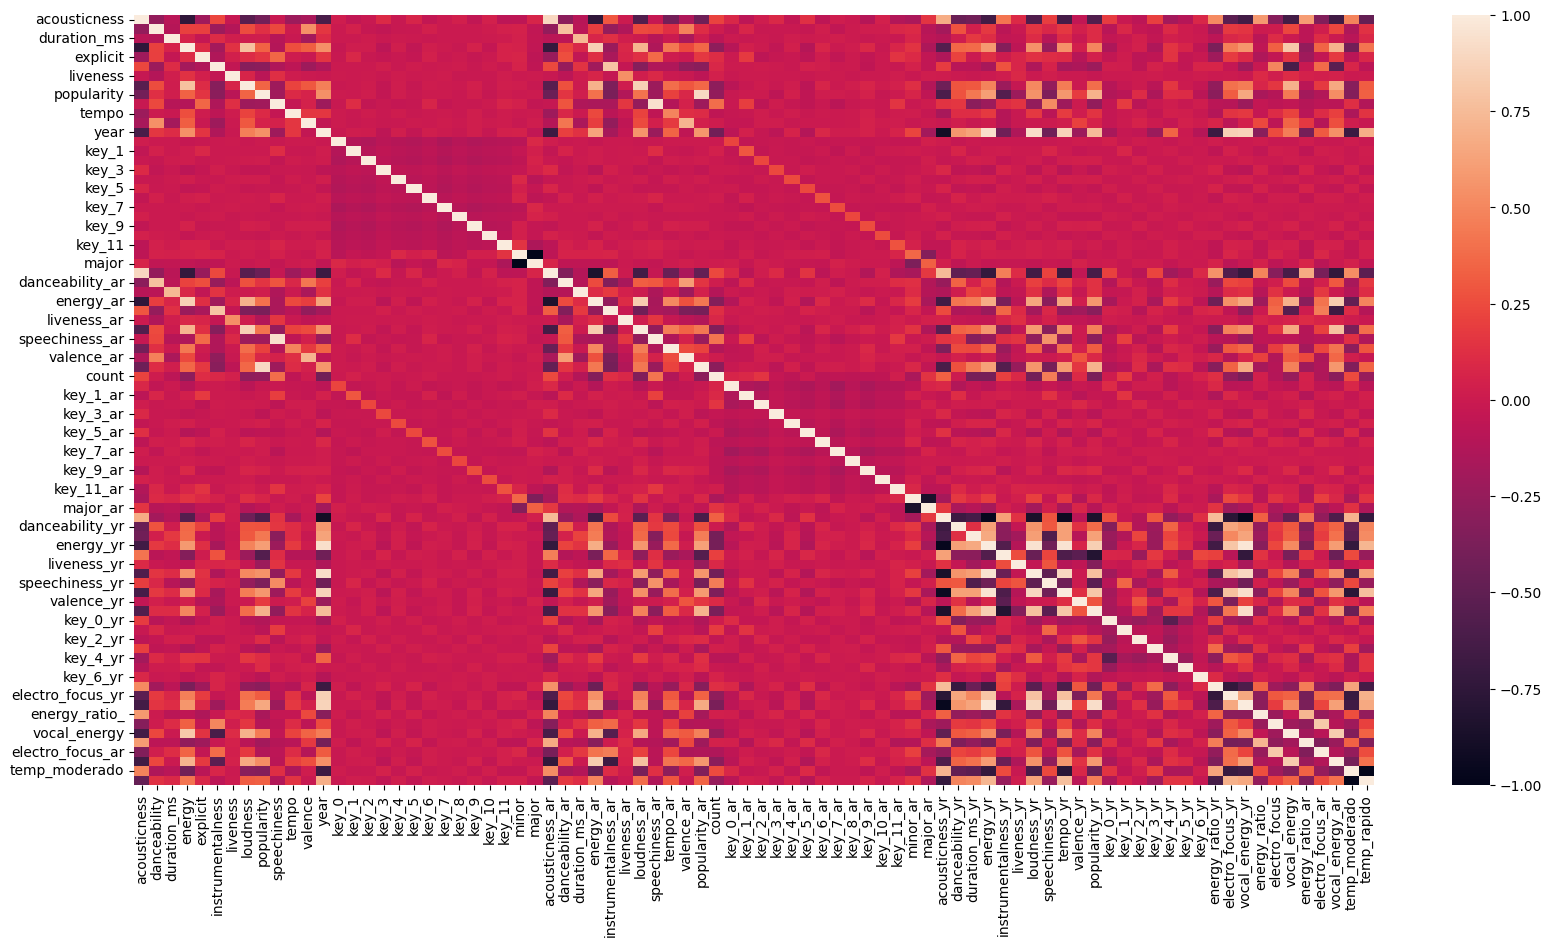

In [51]:
plt.figure(figsize=(20,10))
sns.heatmap(corr)

<Axes: title={'center': 'distribución de la popularidad'}, ylabel='Frequency'>

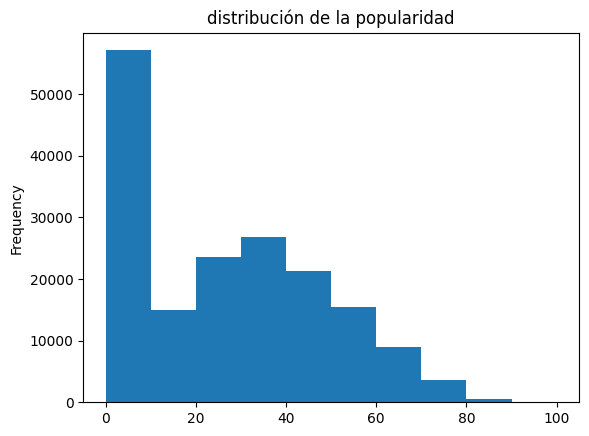

In [10]:
df['popularity'].plot(kind='hist',title='distribución de la popularidad')

In [53]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()


def categorize_popularity(popularity):
    if popularity == 0:
        return 0 #no popular
    elif popularity<=20:
        return 1 # baja
    elif popularity <=40:
        return 2 # media
    return 3 # alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['no popular','Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (no popular): 39729 (23.1%)
   1 (Baja): 34033 (19.8%)
   2 (Media): 51035 (29.6%)
   3 (Alta): 47433 (27.5%)


In [ ]:


_X = df_processed.copy()
X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



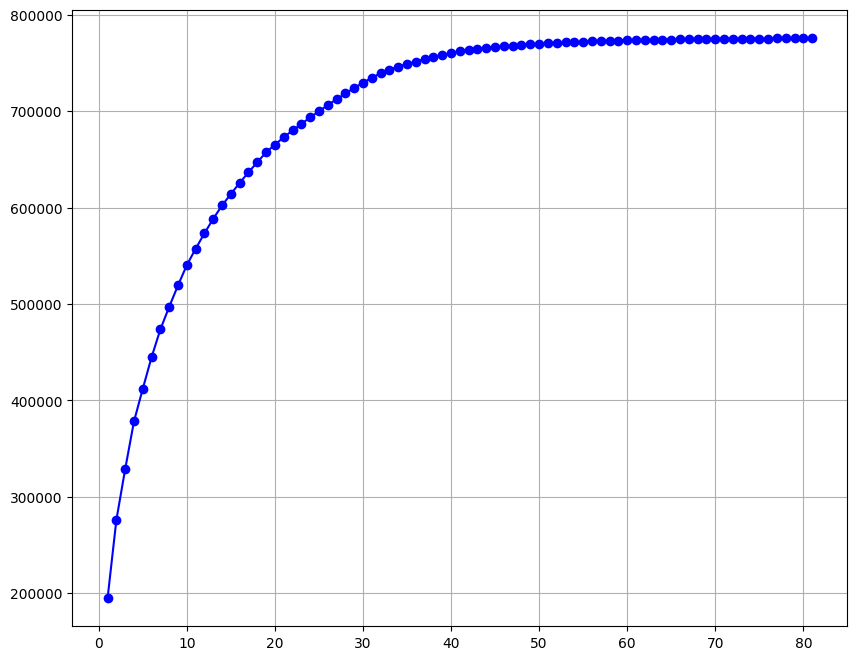

In [55]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.cumsum(np.sort(total_score)[::-1])
plt.figure(figsize=(10,8))
plt.grid(visible=True)
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [56]:
selector = SelectKBest(score_func=f_classif,k=40)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['acousticness', 'energy', 'explicit', 'instrumentalness',
       'loudness', 'speechiness', 'year', 'acousticness_ar', 'energy_ar',
       'instrumentalness_ar', 'loudness_ar', 'speechiness_ar', 'tempo_ar',
       'popularity_ar', 'count', 'acousticness_yr', 'danceability_yr',
       'duration_ms_yr', 'energy_yr', 'instrumentalness_yr',
       'liveness_yr', 'loudness_yr', 'speechiness_yr', 'tempo_yr',
       'valence_yr', 'popularity_yr', 'key_0_yr', 'key_1_yr', 'key_2_yr',
       'key_3_yr', 'key_4_yr', 'key_5_yr', 'energy_ratio_yr',
       'electro_focus_yr', 'vocal_energy_yr', 'vocal_energy',
       'energy_ratio_ar', 'vocal_energy_ar', 'temp_moderado',
       'temp_rapido'], dtype=object)

In [57]:
_X=X[select]

y =y_multiclass_3
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, 
)
from sklearn.preprocessing import RobustScaler

<Axes: >

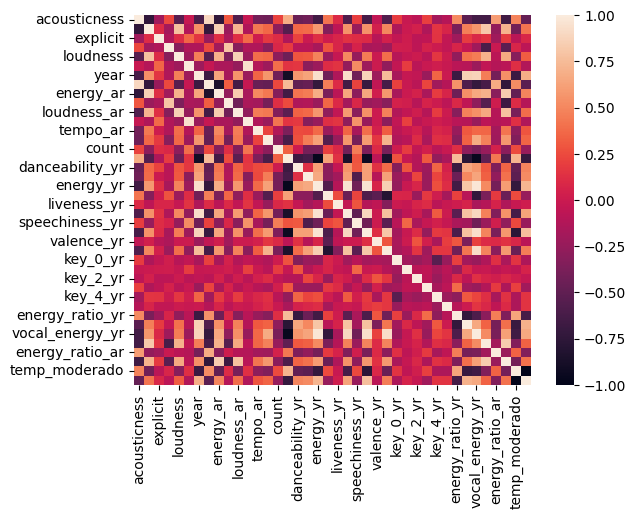

In [58]:
c = _X.corr()
sns.heatmap(c)

In [ ]:
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)

pca = PCA(n_components=0.95)
X_train_reduce=pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)

# K=40

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.9min
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.9min
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.9min
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.9min
[CV] END ...................max_depth=None, n_estimators=100; total time= 2.9min
[CV] END ...................max_depth=None, n_estimators=300; total time= 8.2min
[CV] END ...................max_depth=None, n_estimators=300; total time= 8.2min
[CV] END ...................max_depth=None, n_estimators=300; total time= 8.2min
[CV] END .....................max_depth=10, n_estimators=100; total time= 1.5min
[CV] END ...................max_depth=None, n_estimators=300; total time= 7.9min
[CV] END ...................max_depth=None, n_estimators=300; total time= 7.9min
[CV] END .....................max_depth=10, n_est

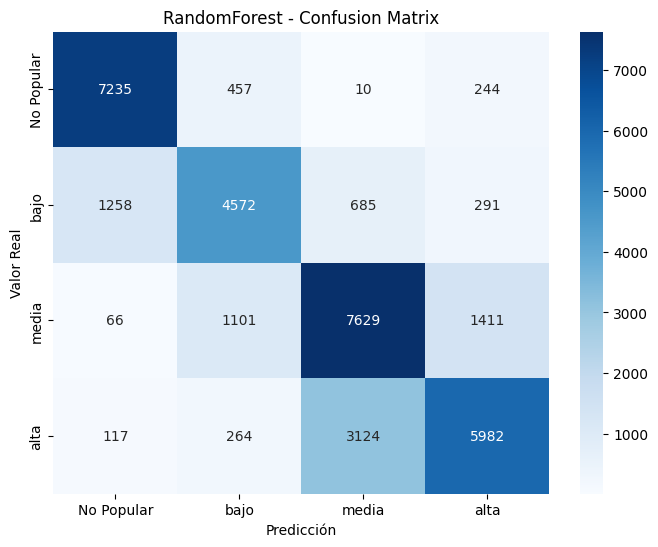


random
              precision    recall  f1-score   support

           0       0.23      0.25      0.24      7946
           1       0.20      0.25      0.22      6806
           2       0.29      0.25      0.27     10207
           3       0.27      0.25      0.26      9487

    accuracy                           0.25     34446
   macro avg       0.25      0.25      0.25     34446
weighted avg       0.25      0.25      0.25     34446



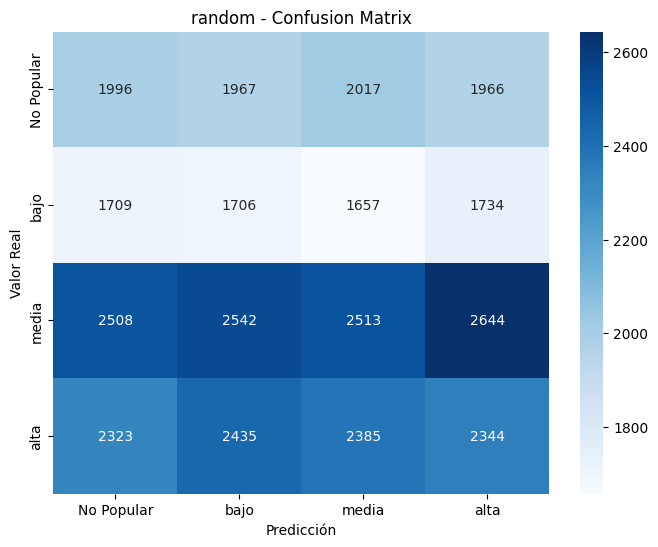

In [60]:

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),

}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

# K=30


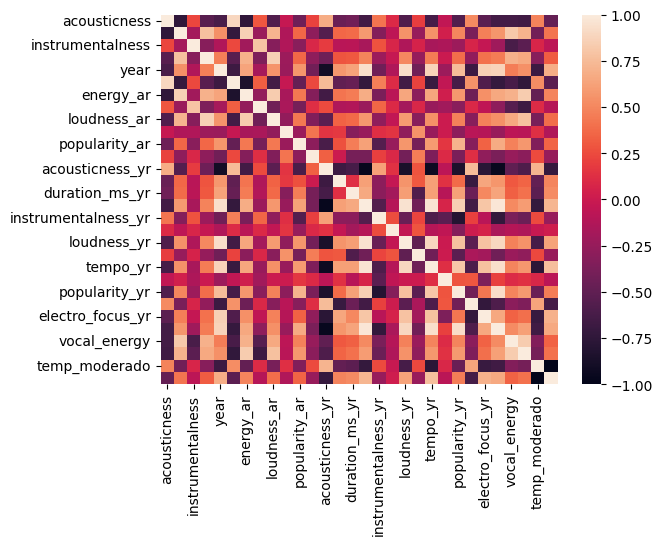


RandomForest
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      7946
           1       0.72      0.70      0.71      6806
           2       0.67      0.75      0.71     10207
           3       0.78      0.65      0.71      9487

    accuracy                           0.75     34446
   macro avg       0.75      0.75      0.75     34446
weighted avg       0.75      0.75      0.75     34446



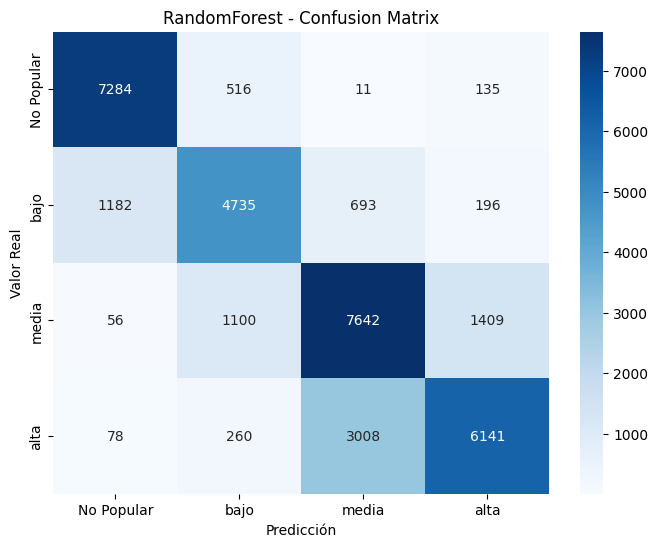


random
              precision    recall  f1-score   support

           0       0.23      0.25      0.24      7946
           1       0.20      0.25      0.22      6806
           2       0.29      0.25      0.27     10207
           3       0.28      0.25      0.26      9487

    accuracy                           0.25     34446
   macro avg       0.25      0.25      0.25     34446
weighted avg       0.26      0.25      0.25     34446



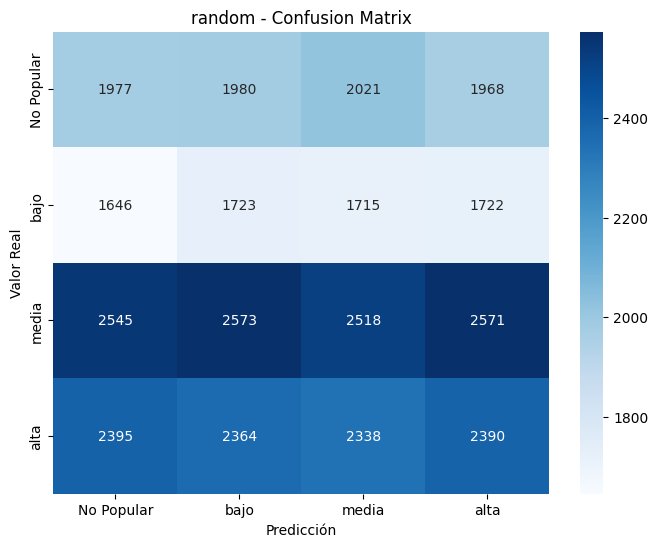

In [61]:
selector = SelectKBest(score_func=f_classif,k=30)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
c = _X.corr()
sns.heatmap(c)
plt.show()
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
pca = PCA(n_components=0.95)
X_train_reduce=pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),

}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

# K=20

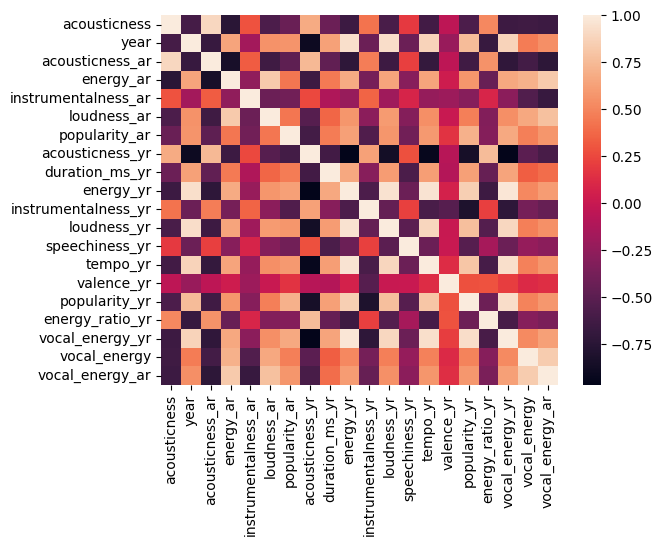


RandomForest
Best params: {'max_depth': 20, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7946
           1       0.74      0.74      0.74      6806
           2       0.69      0.77      0.73     10207
           3       0.82      0.68      0.74      9487

    accuracy                           0.78     34446
   macro avg       0.78      0.78      0.78     34446
weighted avg       0.78      0.78      0.77     34446



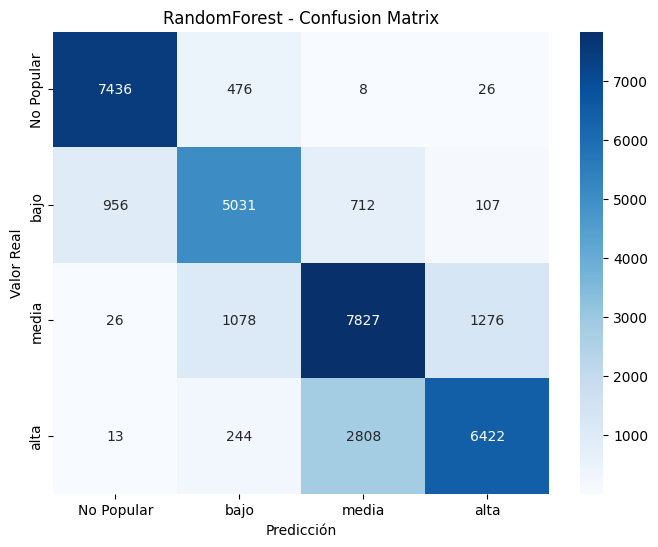


random
              precision    recall  f1-score   support

           0       0.23      0.24      0.23      7946
           1       0.20      0.26      0.23      6806
           2       0.30      0.25      0.27     10207
           3       0.27      0.25      0.26      9487

    accuracy                           0.25     34446
   macro avg       0.25      0.25      0.25     34446
weighted avg       0.26      0.25      0.25     34446



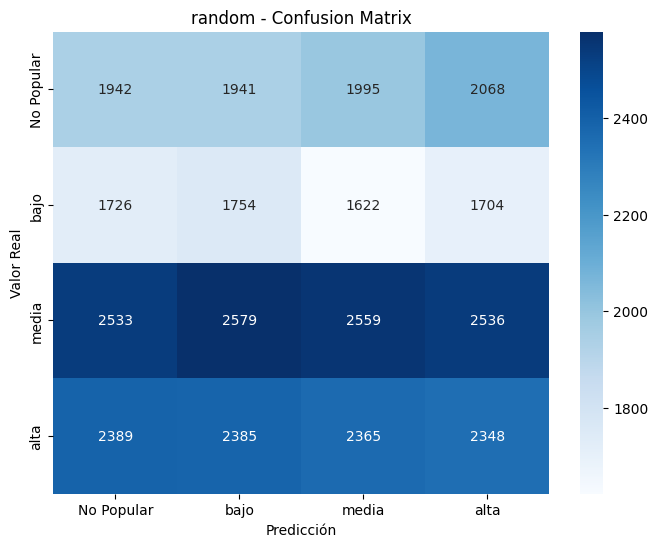

In [62]:
selector = SelectKBest(score_func=f_classif,k=20)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
c = _X.corr()
sns.heatmap(c)
plt.show()
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
pca = PCA(n_components=0.95)
X_train_reduce=pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),

}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

# k=10

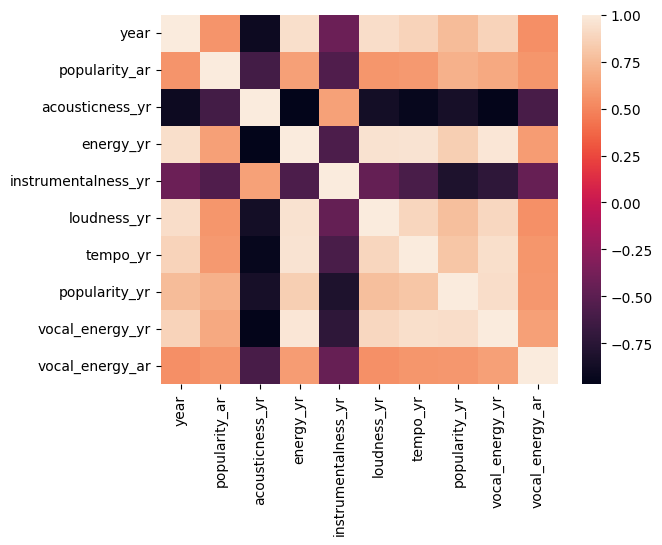


RandomForest
Best params: {'max_depth': 20, 'n_estimators': 500}
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7946
           1       0.76      0.81      0.78      6806
           2       0.71      0.77      0.74     10207
           3       0.83      0.71      0.76      9487

    accuracy                           0.80     34446
   macro avg       0.80      0.81      0.80     34446
weighted avg       0.80      0.80      0.80     34446



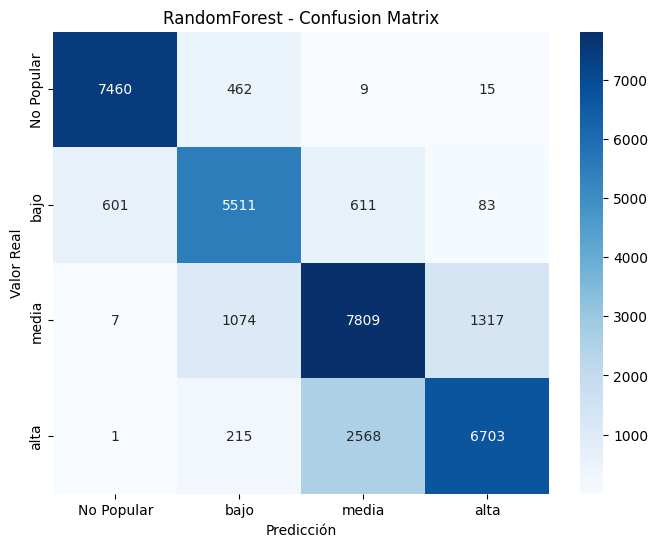


random
              precision    recall  f1-score   support

           0       0.23      0.26      0.24      7946
           1       0.20      0.25      0.22      6806
           2       0.30      0.25      0.27     10207
           3       0.28      0.25      0.26      9487

    accuracy                           0.25     34446
   macro avg       0.25      0.25      0.25     34446
weighted avg       0.26      0.25      0.25     34446



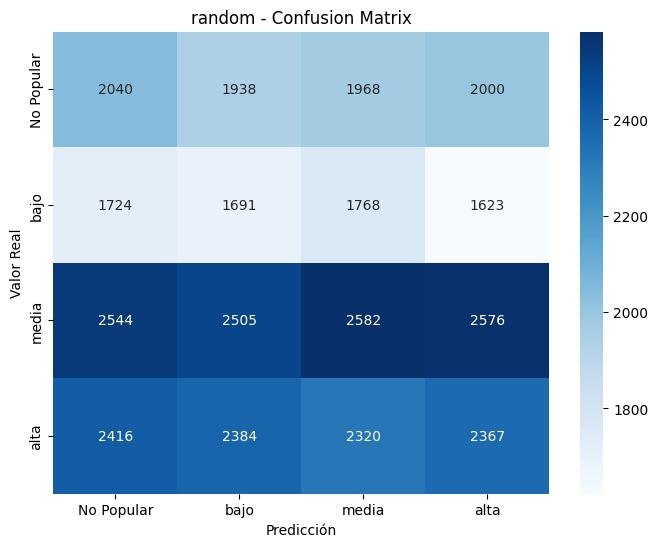

In [63]:
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
c = _X.corr()
sns.heatmap(c)
plt.show()
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
pca = PCA(n_components=0.95)
X_train_reduce=pca.fit_transform(X_train_reduce)
X_test_scaled = pca.transform(X_test_scaled)
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced'),

}
param_grids = {
    
    'RandomForest': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20]
    },
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    results[name] = grid.best_params_

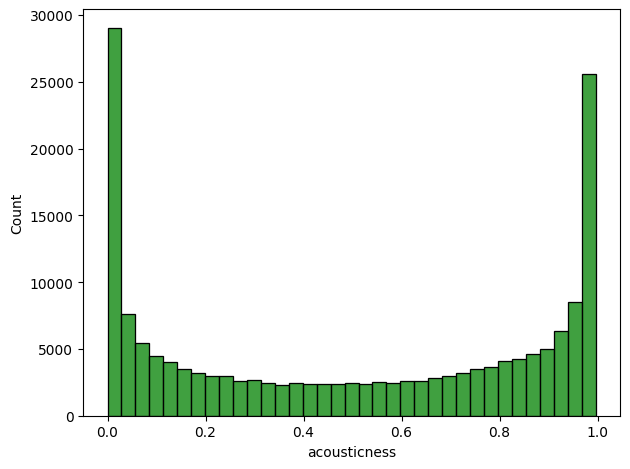

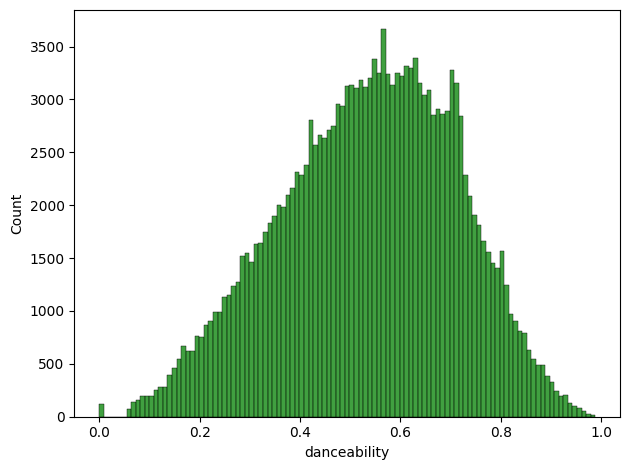

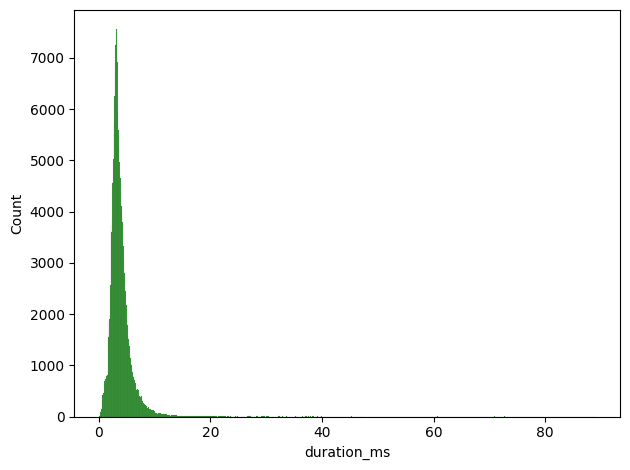

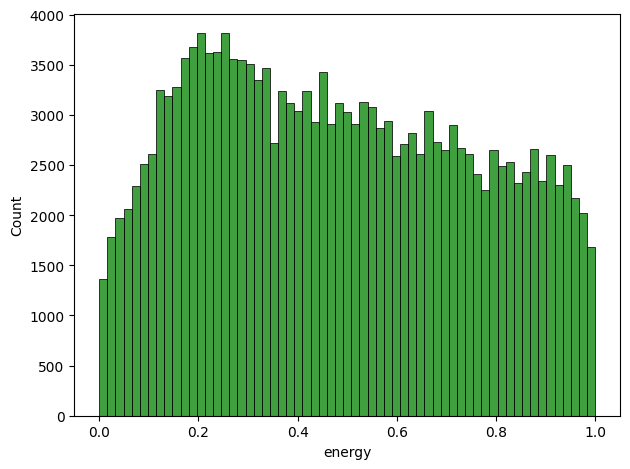

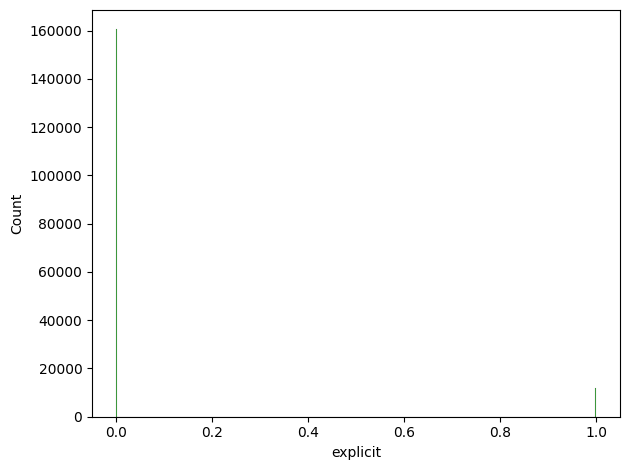

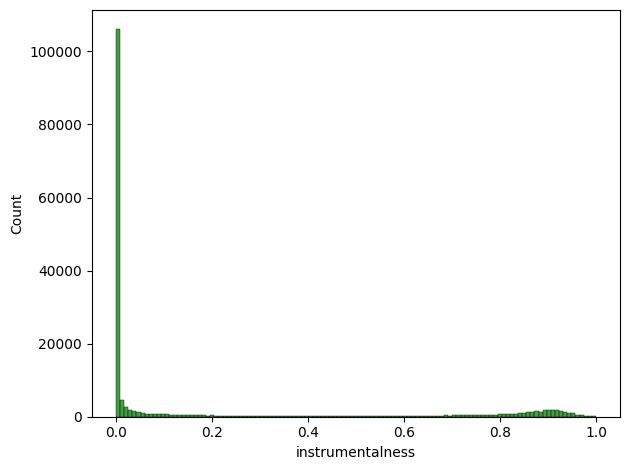

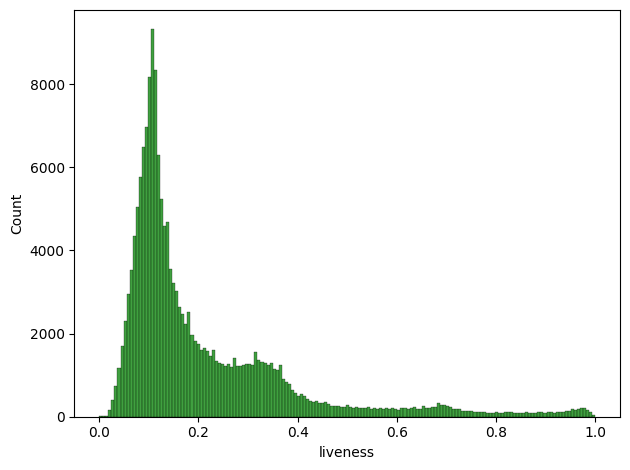

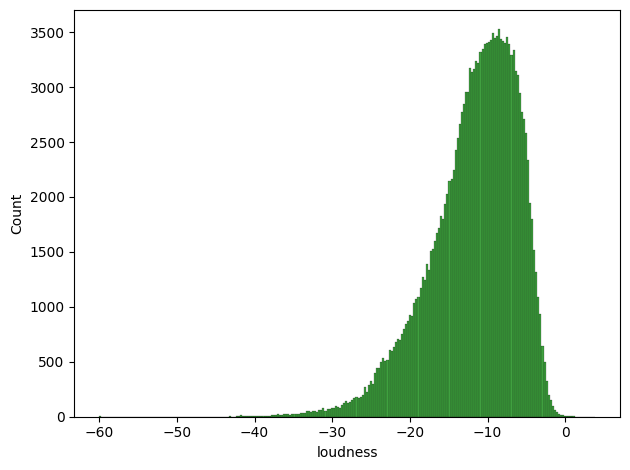

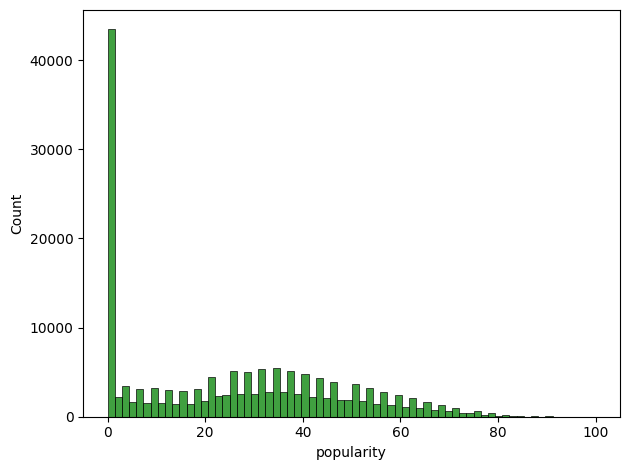

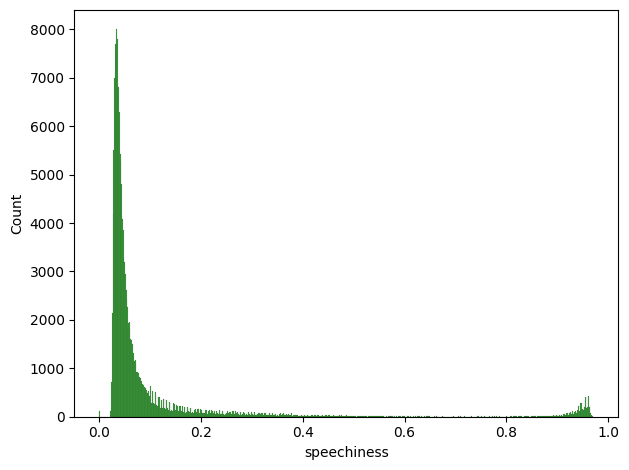

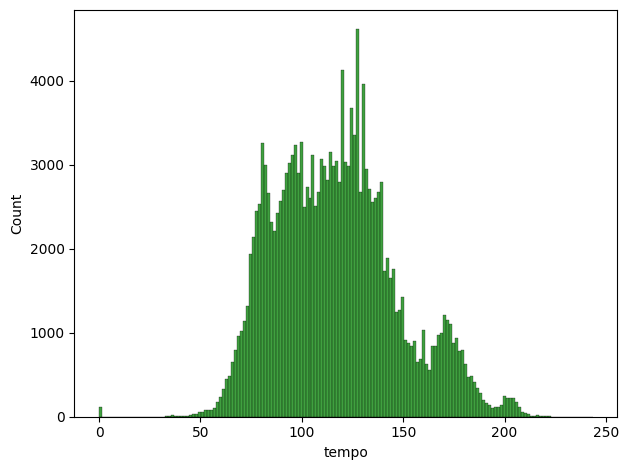

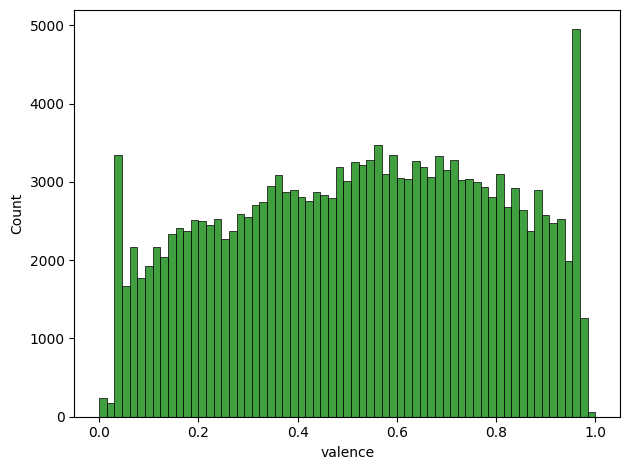

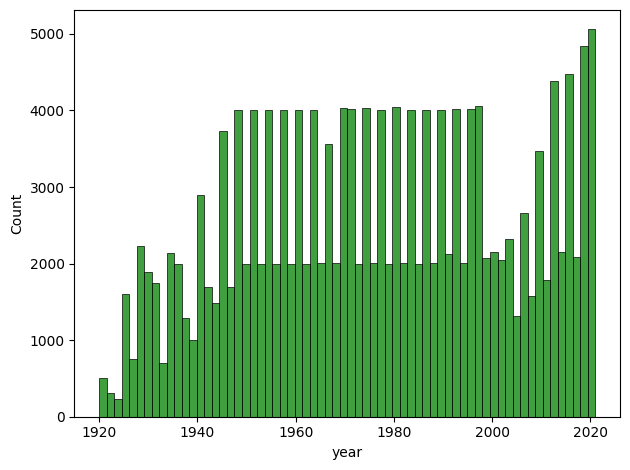

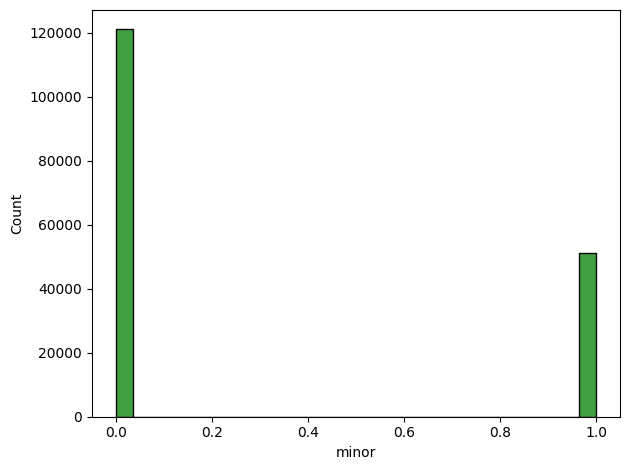

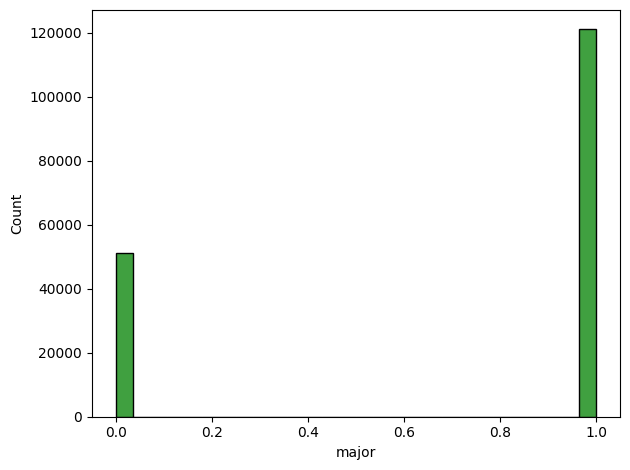

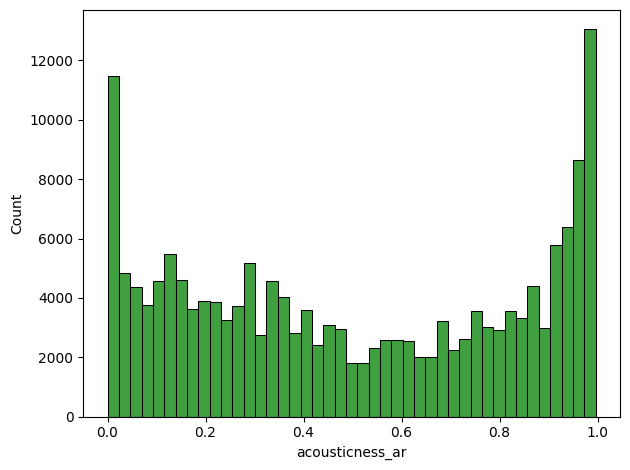

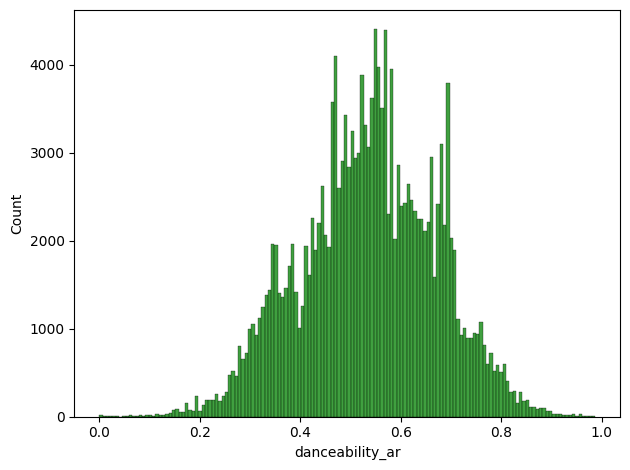

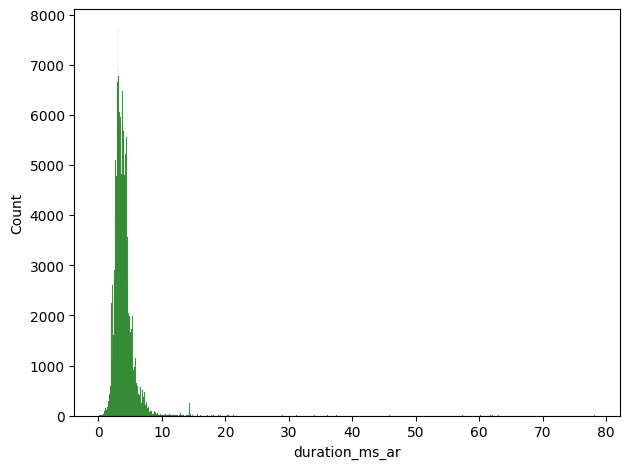

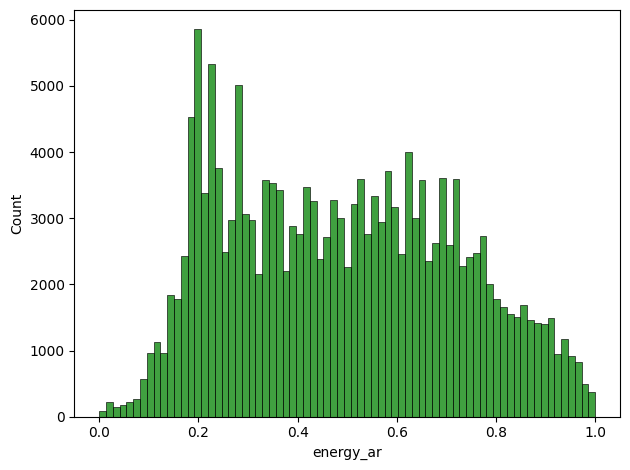

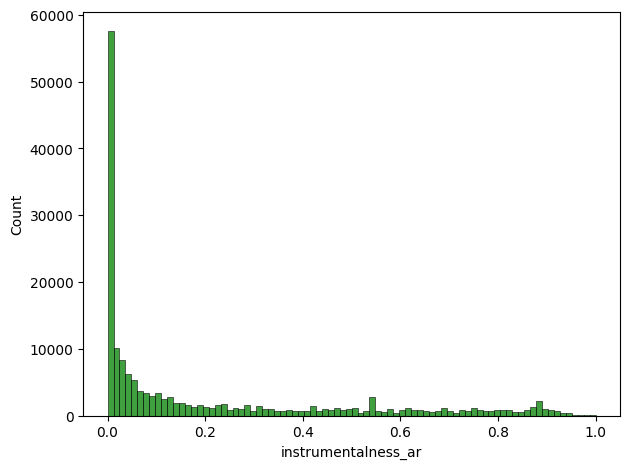

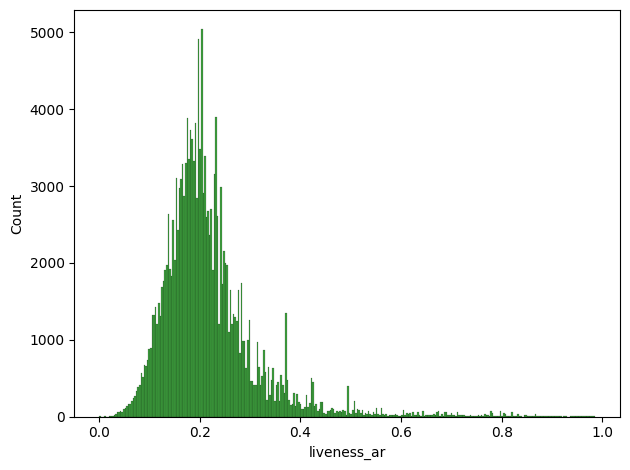

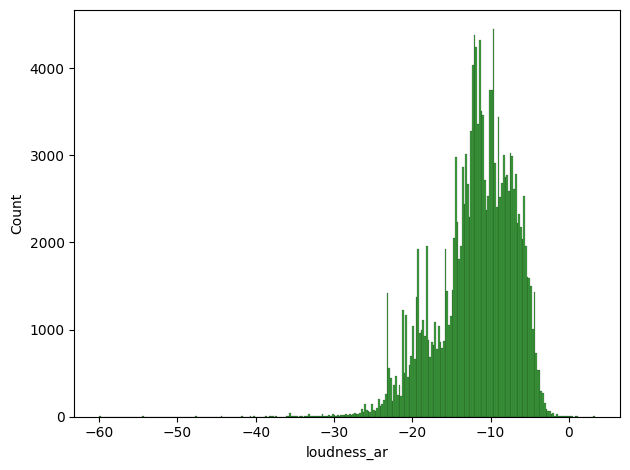

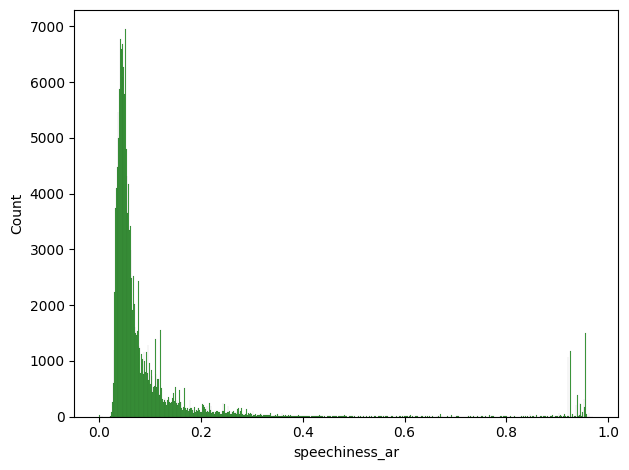

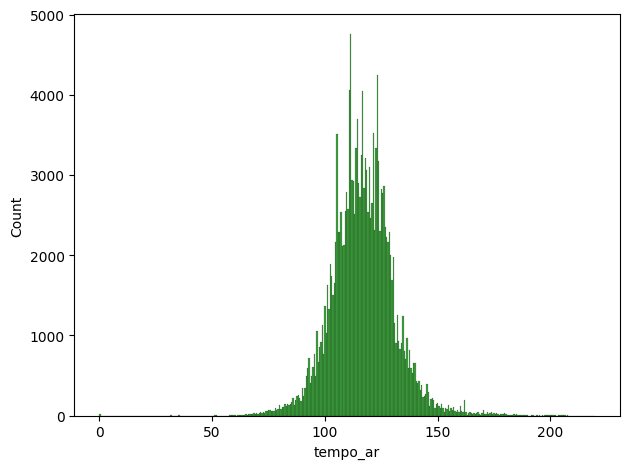

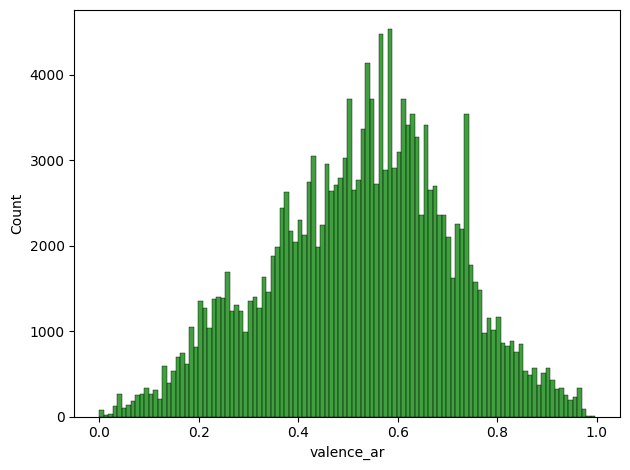

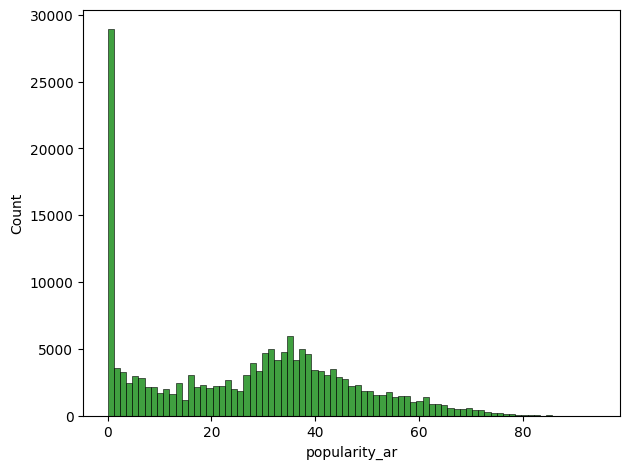

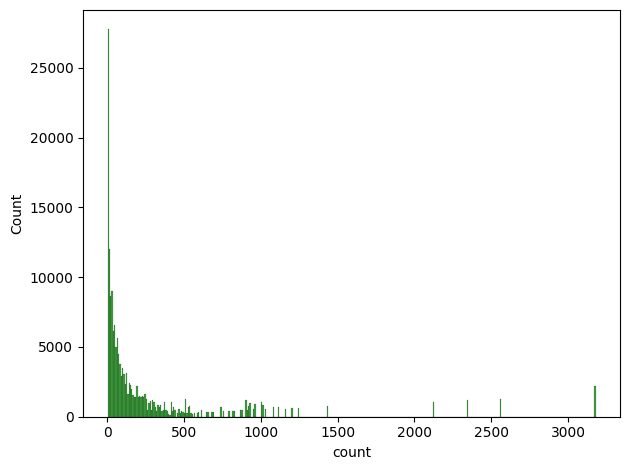

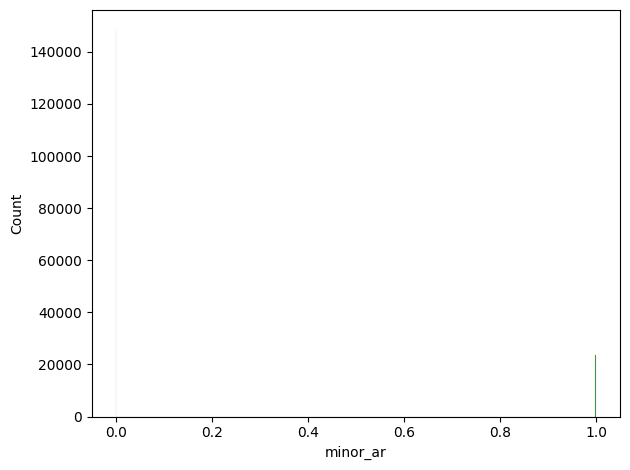

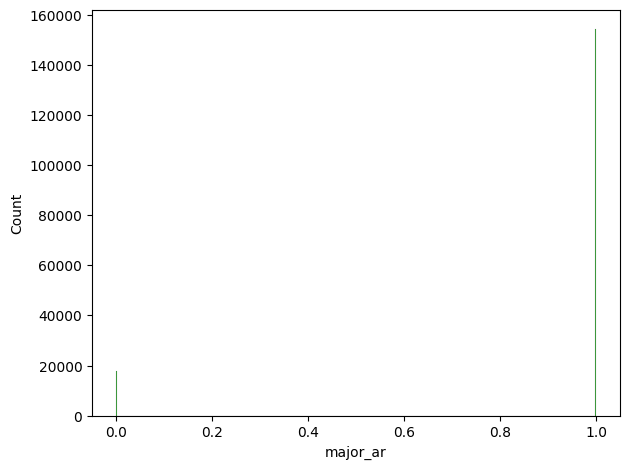

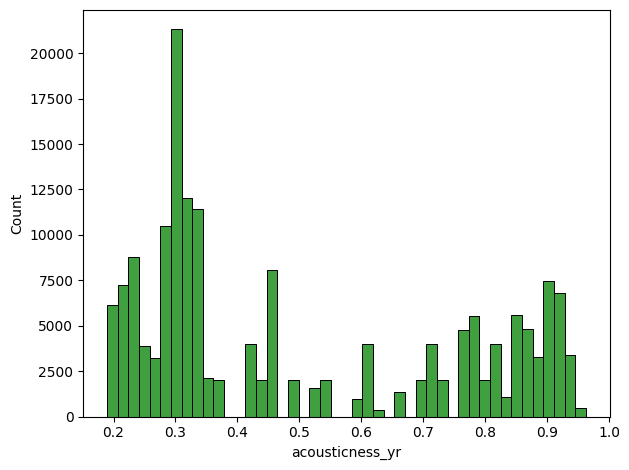

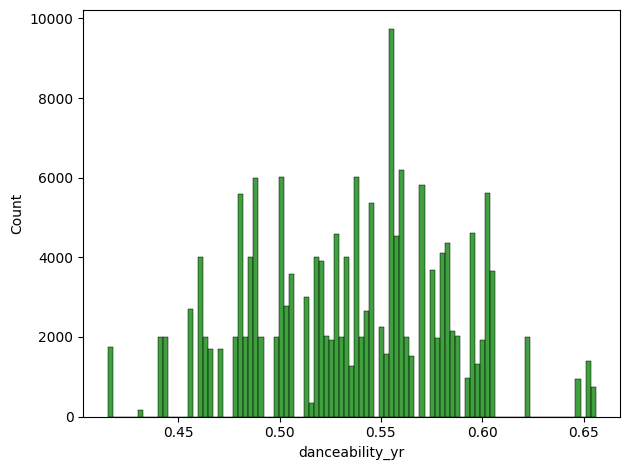

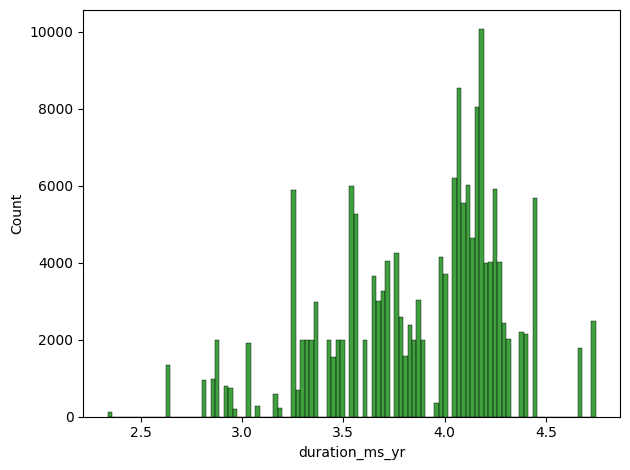

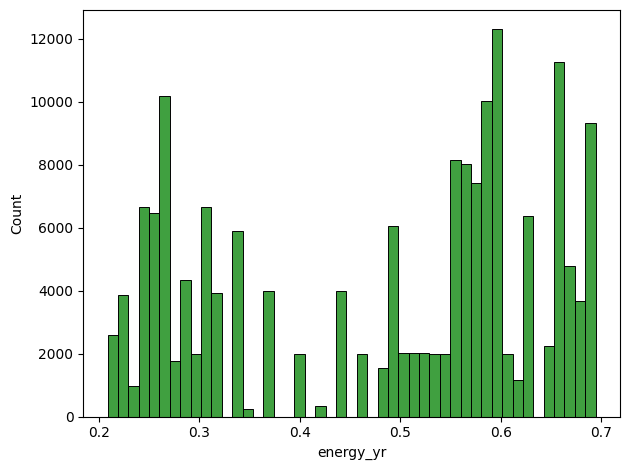

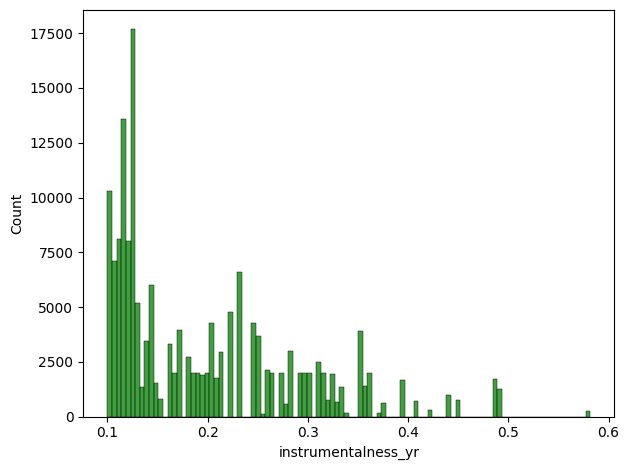

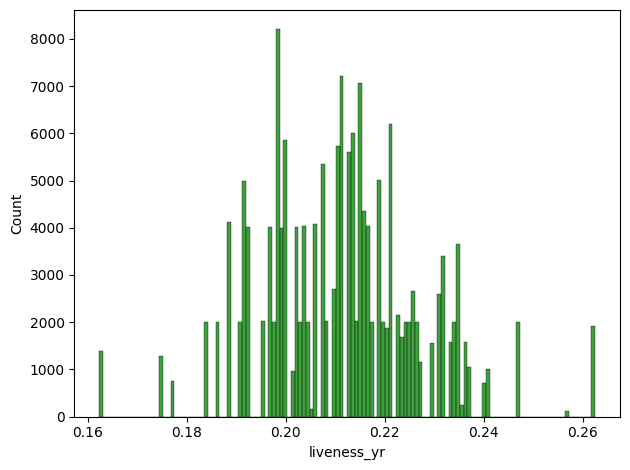

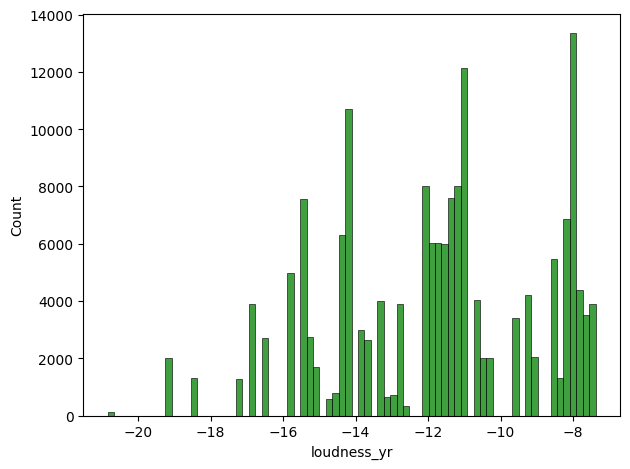

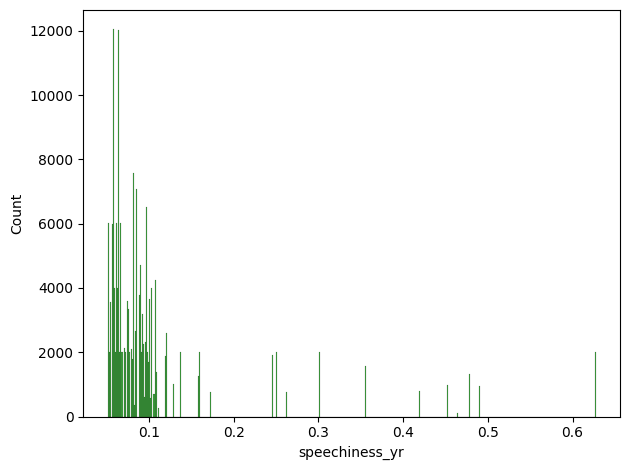

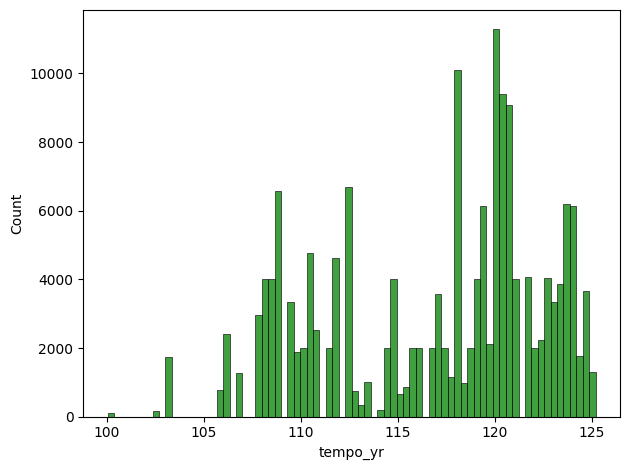

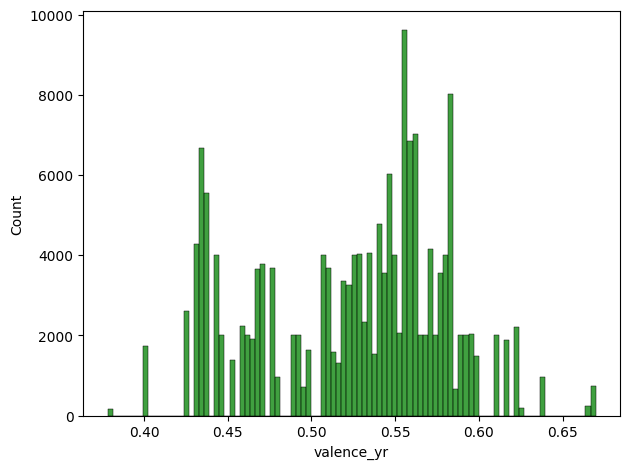

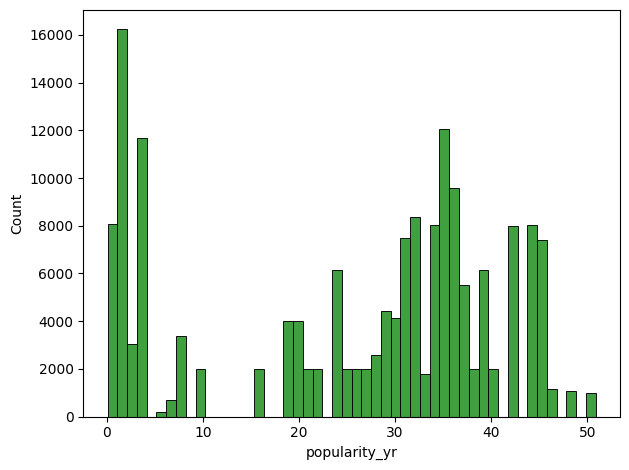

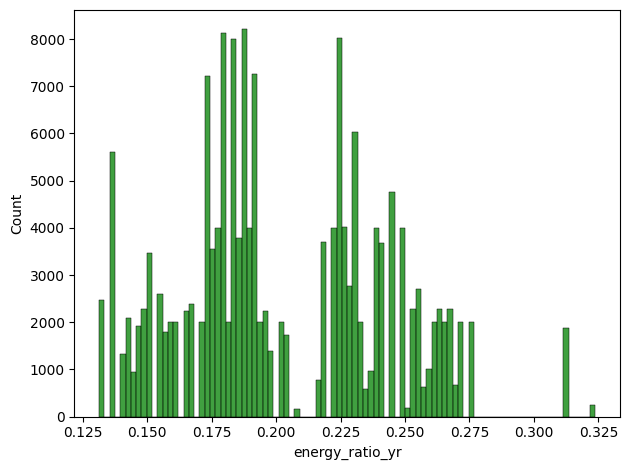

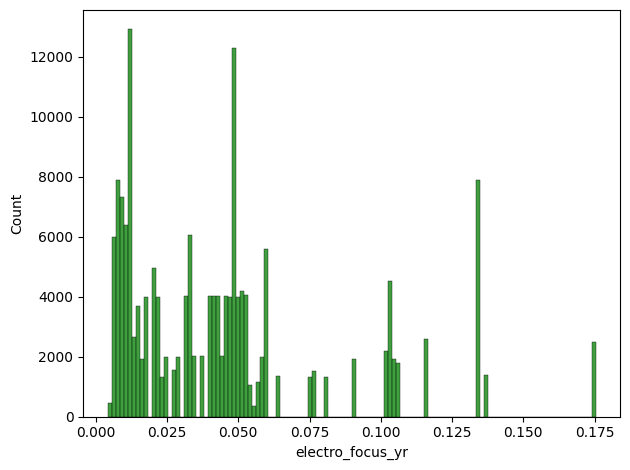

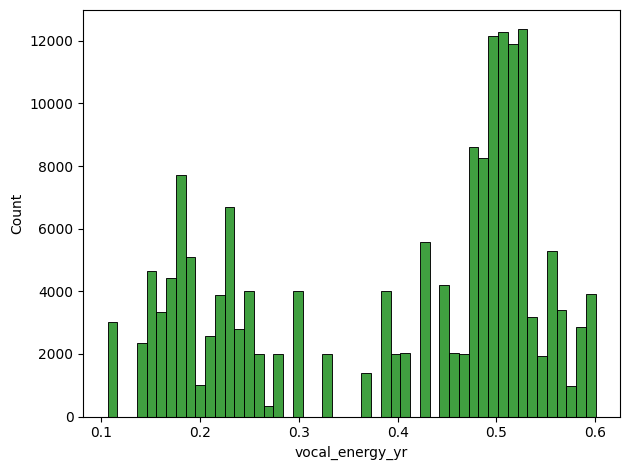

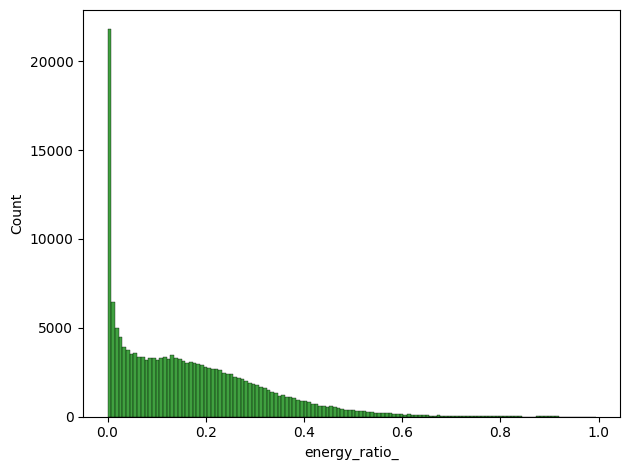

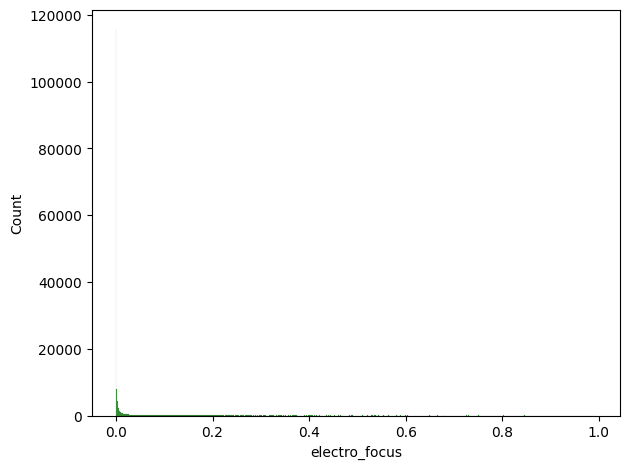

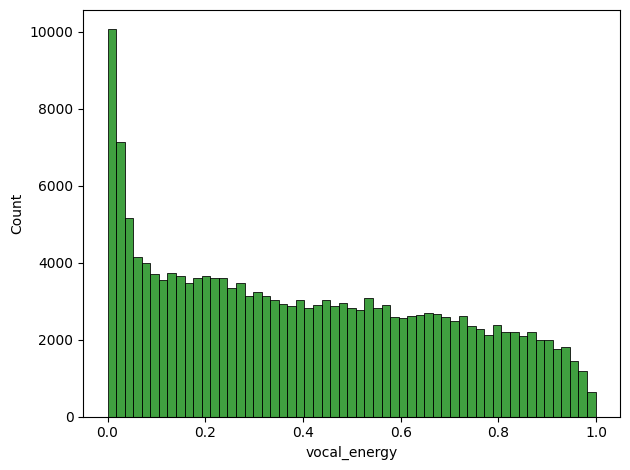

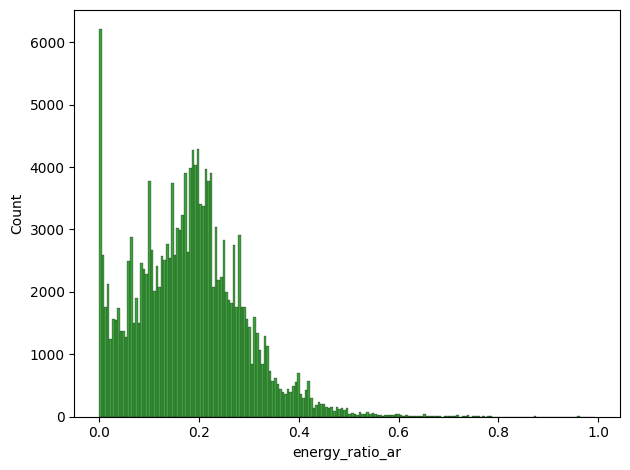

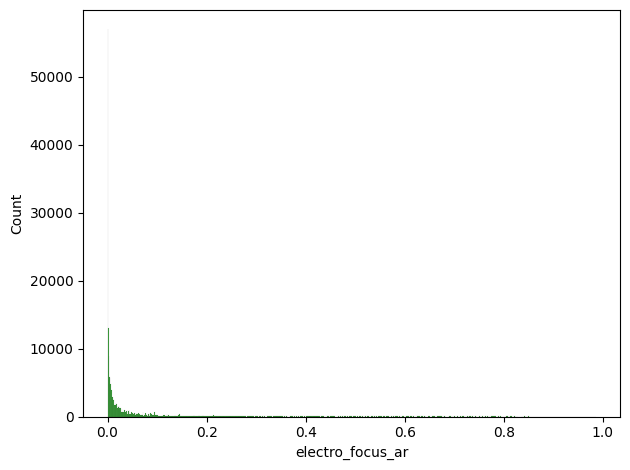

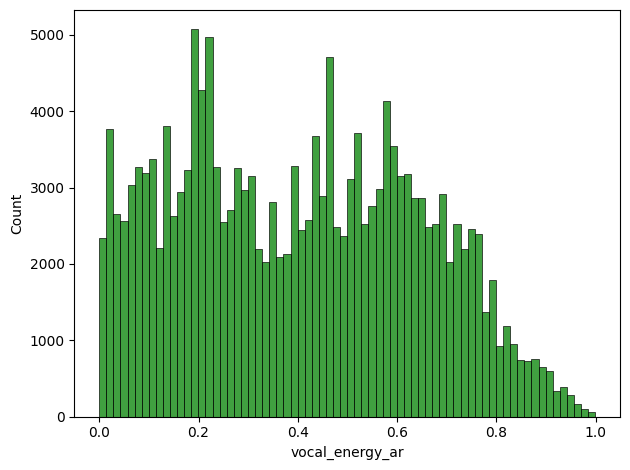

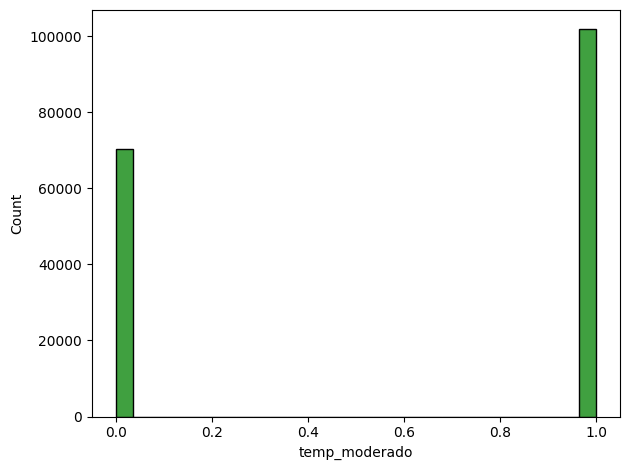

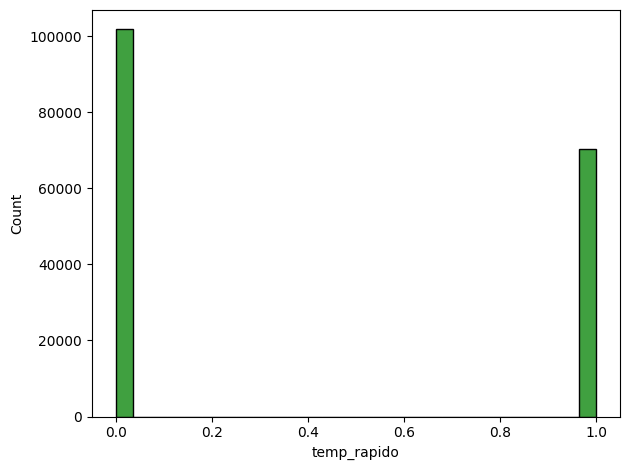

In [64]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
newdf = df.select_dtypes(include=numerics)
l = [x for x in newdf.columns.values if not 'key' in x] 

a=0

for name in l:
    try:
        i,j = divmod(a, 10)
        sns.histplot(x = newdf[name] ,  color='green')
        plt.tight_layout()
        plt.show()
        a += 1
    except:
        pass

